In [1]:
import pennylane as qml
from pennylane import numpy as np
from scipy.optimize import minimize
from rl_qaoa import *
import random
# Define QAOA depth
depth =1
size = 12
seed = 50
hamming_weight = 6
penalty = 9

# Generate a QUBO matrix that is challenging for classical QAOA optimization
np.random.seed(seed)
Q = generate_upper_triangular_qubo(size, (-1,-3), (2,4), integer=False)
Q_cal = zero_lower_triangle(Q + qubo_to_ising(add_constraint([1]*size,hamming_weight)*penalty))
print(Q)



[[-2.59053903  2.45616621  2.51094785  2.79265982  2.7546302   3.99314846
   2.8163944   3.54378799  3.52107338  2.6200187   2.69308241  2.70352963]
 [ 0.         -1.07406683  3.81835688  3.11991421  2.62718149  3.77640008
   3.34914613  2.7821749   3.01436825  3.04820701  3.85600186  3.14274614]
 [ 0.          0.         -2.4690822   2.11280328  2.35965539  3.85186635
   3.87603045  3.42818541  3.46537522  2.92349535  3.86265854  2.81284049]
 [ 0.          0.          0.         -2.54514173  3.36471434  3.75611261
   3.59343453  2.8640045   3.83575644  3.56366736  3.45150056  2.24970939]
 [ 0.          0.          0.          0.         -1.48884905  2.51067783
   3.67799178  2.3572384   2.45422834  3.31975289  2.95823249  2.14689468]
 [ 0.          0.          0.          0.          0.         -2.97015372
   3.05332818  3.84452538  3.83851403  2.50401773  3.36526522  3.92855224]
 [ 0.          0.          0.          0.          0.          0.
  -2.35001169  2.06973066  2.02781073  3

In [ ]:
## Optimization with randomstate
# Initial parameters for QAOA
n = Q.shape[0]
n_c = 3

np.random.seed(seed)
init_params = np.reshape(np.array([-0.12107375,  0.24919166]*(n-n_c)),-1)


# RL-QAOA setup
rl_qaoa = RL_QAOA(Q_cal,n,init_params,b_vector = np.array([[25.]*int((n**2))]),QAOA_depth=depth,gamma = 0.99,learning_rate_init=[0.00,0.5])
final_config = rl_qaoa.rqaoa_execute()
rl_qaoa.n_c =n_c
print(f"classical_result : {float(final_config[2])},best : {rl_qaoa.node_assignments}" )


# Execute RQAOA
final_config = rl_qaoa.RL_QAOA(episodes=50,epochs=200,log_interval=10,correct_ans=float(final_config[2]))

classical_result : -45.78315408949319,best : [1, -1, 1, 1, -1, 1, -1, -1, -1, 1, 1, -1]


Epoch 1/200:   0%|          | 0/50 [00:00<?, ? episode/s]


IndexError: index 1 is out of bounds for axis 0 with size 1

In [3]:
## Optimization with randomstate
# Initial parameters for QAOA
n = Q.shape[0]
n_c = 3

np.random.seed(seed)
init_params = np.reshape(np.array( [-0.12107375,  0.24919166]*(n-n_c)),-1)


# RL-QAOA setup
rl_qaoa_const = RL_QAOA_constraint(Q,n,init_params,b_vector = np.array([25.]*int((n**2))) ,hamming_weight=hamming_weight,penalty=penalty,QAOA_depth=depth,gamma = 0.99,learning_rate_init=[0.00,0.5])
final_config = rl_qaoa_const.rqaoa_execute()
rl_qaoa_const.n_c =n_c
print(f"classical_result : {float(final_config[2])},best : {rl_qaoa_const.node_assignments}" )


# Execute RQAOA
final_config = rl_qaoa_const.RL_QAOA(episodes=50,epochs=200,log_interval=10,correct_ans=float(final_config[2]))

classical_result : -59.283154089493195,best : [1, -1, 1, 1, -1, 1, -1, -1, -1, 1, 1, -1]


Epoch 1/200: 100%|██████████| 50/50 [00:27<00:00,  1.79 episode/s]


  Probability of finding correct solution: 0.0200
  Average reward: -53.3141322655096
  Lowest reward obtained: -59.283154089493195
  Best state at lowest value: [ 1 -1  1  1 -1  1 -1 -1 -1  1  1 -1]
  passed episodes : 47
  number of nodes : 435


Epoch 11/200: 100%|██████████| 50/50 [00:24<00:00,  2.07 episode/s]


  Probability of finding correct solution: 0.0200
  Average reward: -52.692197057752765
  Lowest reward obtained: -59.283154089493195
  Best state at lowest value: [ 1 -1  1  1 -1  1 -1 -1 -1  1  1 -1]
  passed episodes : 45
  number of nodes : 4394


...

  Probability of finding correct solution: 0.0600
  Average reward: -52.13842882298225
  Lowest reward obtained: -59.283154089493195
  Best state at lowest value: [ 1 -1  1  1 -1  1 -1 -1 -1  1  1 -1]
  passed episodes : 43
  number of nodes : 22898


Epoch 71/200: 100%|██████████| 50/50 [00:18<00:00,  2.65 episode/s]


  Probability of finding correct solution: 0.0000
  Average reward: -52.35471288138005
  Lowest reward obtained: -58.440006268136294
  Best state at lowest value: [-1 -1 -1 -1 -1  1  1  1  1  1  1 -1]
  passed episodes : 44
  number of nodes : 26420


Epoch 78/200:  58%|█████▊    | 29/50 [00:12<00:09,  2.31 episode/s]


KeyboardInterrupt: 

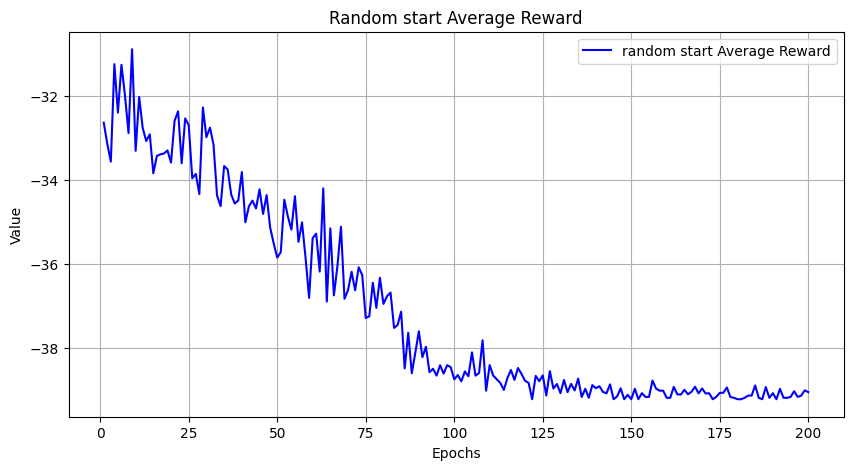

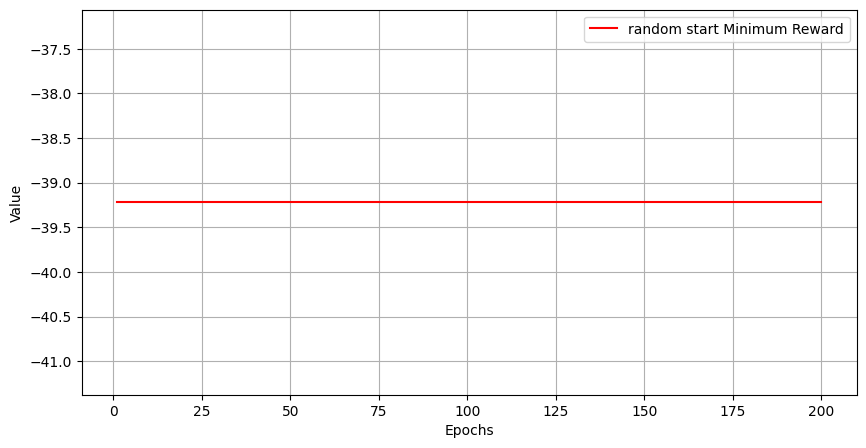

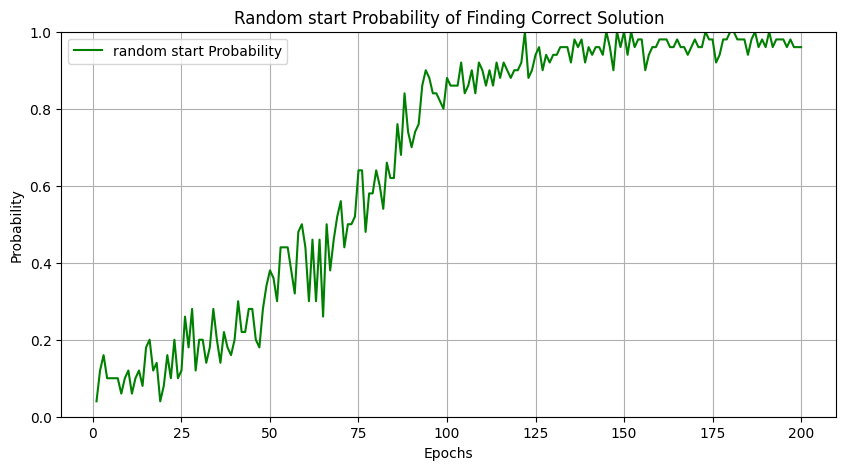

In [ ]:
import matplotlib.pyplot as plt

def plot_rl_qaoa_results(avg_values, min_values, prob_values):
    """
    Plots the stored training values of RL_QAOA across epochs with margin.

    - The first plot shows the average values over epochs with margin.
    - The second plot displays the minimum values over epochs with margin.
    - The third plot represents the probability of finding the correct solution.

    Parameters
    ----------
    avg_values : list
        List of average values over epochs.
    min_values : list
        List of minimum values over epochs.
    prob_values : list
        List of probabilities over epochs.

    The x-axis represents the number of epochs in all graphs.
    """

    epochs = range(1, len(avg_values) + 1)

    # Calculate margins for y-axis limits
    avg_min, avg_max = min(avg_values), max(avg_values)
    min_min, min_max = min(min_values), max(min_values)

    avg_margin = (avg_max - avg_min) * 0.05
    min_margin = (min_max - min_min) * 0.05

    # Plot average values with margin
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, avg_values, label="random start Average Reward", color='blue')
    plt.xlabel("Epochs")
    plt.ylabel("Value")
    plt.title("Random start Average Reward")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Plot minimum values with margin
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, min_values, label="random start Minimum Reward", color='red')
    plt.xlabel("Epochs")
    plt.ylabel("Value")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Plot probability values
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, prob_values, label="random start Probability", color='green')
    plt.xlabel("Epochs")
    plt.ylabel("Probability")
    plt.title("Random start Probability of Finding Correct Solution")
    plt.ylim(0, 1)  # Setting the y-axis range between 0 and 1
    plt.grid(True)
    plt.legend()
    plt.show()
# Example usage with dummy data
avg_values_random = rl_qaoa.avg_values
min_values_random = rl_qaoa.min_values
prob_values_random = rl_qaoa.prob_values


plot_rl_qaoa_results(avg_values_random, min_values_random, prob_values_random)

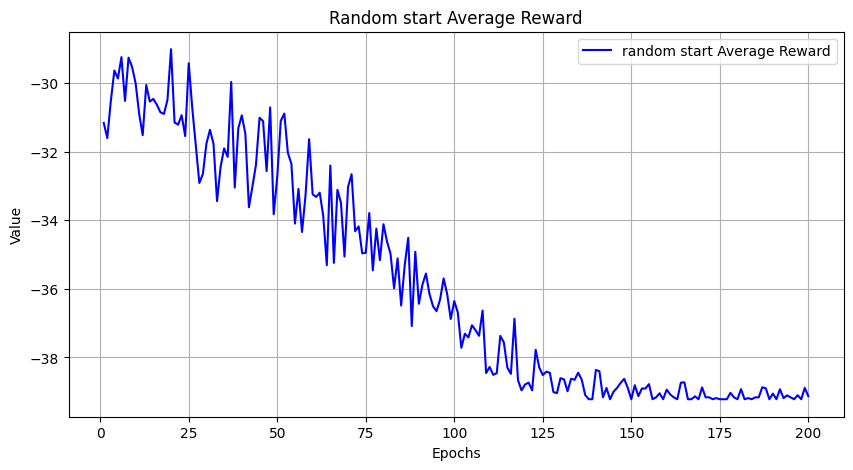

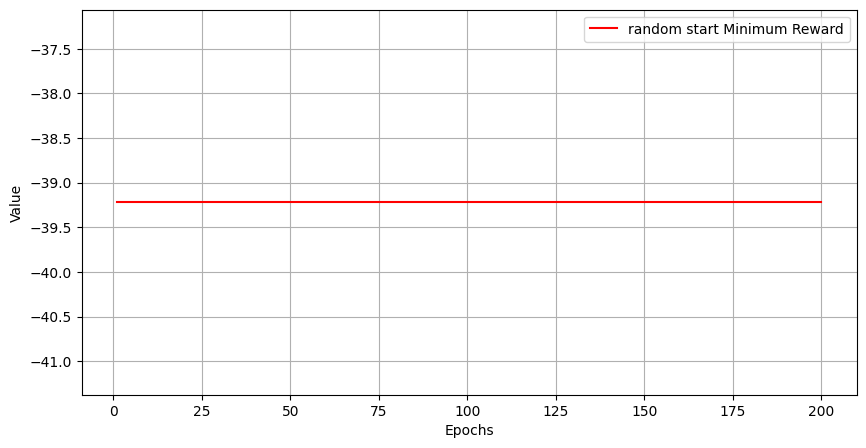

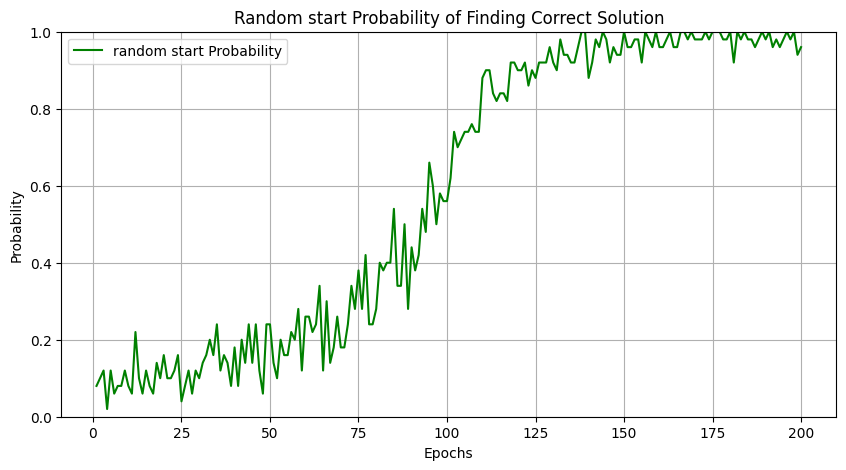

In [ ]:
avg_values_random = rl_qaoa_const.avg_values
min_values_random = rl_qaoa_const.min_values
prob_values_random = rl_qaoa_const.prob_values
plot_rl_qaoa_results(avg_values_random, min_values_random, prob_values_random)


In [ ]:
import pennylane as qml  # Importing PennyLane for quantum computing
from pennylane import numpy as np  # Importing PennyLane's NumPy for compatibility
import torch  # Importing PyTorch for potential machine learning applications
import torch.nn as nn  # Importing PyTorch's neural network module
import copy  # Importing copy module for deep copying objects
import itertools  # Importing itertools for combinatorial operations
from tqdm import tqdm  # Importing tqdm for progress tracking
from scipy.optimize import minimize
import random
import pennylane as qml

import copy
import itertools
import torch
import pennylane as qml
from pulse_simulator import ising_to_qubo
import numpy as npo




import time

def timing_decorator(func):
    def wrapper(*args, **kwargs):
        start_time = time.perf_counter()
        result = func(*args, **kwargs)
        end_time = time.perf_counter()
        elapsed_time = end_time - start_time
        print(f"{func.__name__} execution time: {elapsed_time:.6f} seconds")
        return result
    return wrapper

def ising_to_qubo(ising_matrix):
    """
    for-loop를 이용하여 Ising matrix (h_i와 J_{ij})를 QUBO matrix로 변환.
    
    Args:
        ising_matrix (np.ndarray): n x n 대칭 행렬
    Returns:
        np.ndarray: 변환된 QUBO 행렬
    """
    n = ising_matrix.shape[0]
    Q = np.zeros_like(ising_matrix)
    
    # off-diagonal 항: Q_{ij} = 4 * J_{ij} (i != j)
    for i in range(n):
        for j in range(n):
            if i != j:
                Q[i, j] = 4 * ising_matrix[i, j]
                Q[i,i] -= 2 * ising_matrix[i, j]
                Q[j,j] -= 2 * ising_matrix[i, j]
    # 대각 원소: Q_{ii} = 2*h_i - 2 * sum_{j != i} J_{ij}
    for i in range(n):
        h_i = ising_matrix[i, i]
        Q[i, i] -= 2 * h_i 
        
    return Q


def qubo_to_ising(Q):
    """
    0/1 basis의 QUBO matrix Q (대칭 np.array)를 받아,
    -1/1 basis (Ising)로 변환하여 linear term h와 quadratic interaction matrix J를 반환합니다.
    
    x_i = (1 - z_i) / 2 변환을 이용.
    
    변환된 Ising Hamiltonian:
       H(z) = constant + sum_i h_i * z_i + sum_{i<j} J_{ij} * z_i * z_j.
    
    Parameters:
        Q (np.array): QUBO matrix (대칭, diagonal에 1-body term, off-diagonal에 2-body interaction)

    Returns:
        h (np.array): Ising 모델의 선형 항 계수 (길이 n)
        J (np.array): Ising 모델의 상호작용 계수 (n x n, 대칭, diagonal은 0)
    """
    n = Q.shape[0]
    h = np.zeros(n)
    J = np.zeros((n, n))
    # i<j에 대해 quadratic interaction term 계산
    for i in range(n):
        for j in range(n):
          if i!=j:
            h[i] -= Q[i, j] / 4.0
            h[j] -= Q[i, j] /4
            J[i, j] = Q[i, j] / 4.0

    for i in range(n):
        h[i] -= Q[i, i] / 2.0
    Q_res = J
    np.fill_diagonal(Q_res, h)
    return Q_res


def add_constraint(node_hamming_weights, hamming_weights):
    size = len(node_hamming_weights)
    Q = npo.zeros((size, size))
    for i in range(size):
        for j in range(size):
            if i == j:
                Q[i, j] = node_hamming_weights[i]**2 - 2*hamming_weights*node_hamming_weights[i]
            else:
                Q[i, j] = node_hamming_weights[i]*node_hamming_weights[j]
    
    return Q

def make_check(list_seq):
    list_seq = copy.deepcopy(list_seq)
    full_list = []
    add_comp = None
    for seq in list_seq:
        if len(full_list) == 0:
            full_list =[seq]
        else:
            break_comp = False
            seq_test = abs(npo.array(seq))
            for list_comp in full_list:
                if break_comp:
                    break
                for index,comp in enumerate(list_comp):
                    if break_comp:
                        break
                    for test_idx,test in enumerate(seq_test):
                        if test == abs(comp):
                            test = seq.pop(test_idx)
                            add_comp = npo.sign(test)*npo.sign(comp)*npo.array(seq)
                            break_comp = True
                            list_comp+=list(add_comp)
                            break
                                
                
                
                
            if add_comp is None and len(seq) >= 1:
                full_list.append(seq)
            add_comp = None
    return full_list

def make_node_weights(full_list):
    node_weights = []
    hamming_weights_default = 0
    for seq in full_list:
        node_weights.append(np.sum(np.array(seq) >= 0) - np.sum(np.array(seq) < 0))
        hamming_weights_default += np.sum(np.array(seq) < 0)
    return node_weights, hamming_weights_default


class TreeNode:
    def __init__(self, key, value):
        """
        Initializes a tree node.
        :param key: The unique identifier for the node.
        :param value: The data associated with the node.
        """
        self.key = key  # Node's unique key
        self.value = value  # Node's stored value
        self.children = {}  # Dictionary to store child nodes (key -> TreeNode mapping)

    def __repr__(self):
        """
        Returns a string representation of the node.
        """
        return f"TreeNode({self.key}: {self.value})"


class Tree:
    def __init__(self, root_key, root_value):
        """
        Initializes a tree with a root node.
        :param root_key: The unique key for the root node.
        :param root_value: The data associated with the root node.
        """
        self.root = TreeNode(root_key, root_value)  # Create the root node
        self.state = self.root  # Set the current state to the root node
        self.node_num = 0
    def has_child(self, key):
        """
        Checks if the current state (node) has a child with the given key.
        :param key: The key of the child node to check.
        :return: True if the child exists, False otherwise.
        """
        return key in self.state.children  # Check if the key exists in the children dictionary

    def move(self, key):
        """
        Moves the current state to a child node if it exists.
        :param key: The key of the child node to move to.
        :raises ValueError: If the child does not exist.
        """
        if self.has_child(key):  # If the child exists, move to it
            self.state = self.state.children[key]

        else:
            raise ValueError(f"Error: No child with key '{key}' exists.")  # Raise an error if child doesn't exist

    def create(self, key, value):
        """
        Creates a new child node under the current state if the key does not already exist.
        :param key: The key of the new child node.
        :param value: The value to store in the new node.
        :raises ValueError: If the key already exists.
        """
        if not self.has_child(key):  # If the child does not exist, create it
            new_node = TreeNode(key, value)
            self.state.children[key] = new_node  # Add the new node to the children dictionary
            self.node_num +=1
        else:
            raise ValueError(f"Error: Child '{key}' already exists.")  # Raise an error if child already exists

    def reset_state(self):
        """
        Resets the current state back to the root node.
        """
        self.state = self.root  # Set state back to the root node


    def display_tree(self, node=None, level=0):
        """
        Recursively prints the structure of the tree.
        :param node: The node to start printing from (default is the root node).
        :param level: The indentation level for printing the tree hierarchy.
        """
        if node is None:  # If no node is provided, start from the root
            node = self.root
        print("  " * level + f"{node.key}: {node.value}")  # Print the current node with indentation
        for child in node.children.values():  # Iterate through all child nodes
            self.display_tree(child, level + 1)  # Recursively print child nodes with increased indentation
            
       


def generate_combinations(n, m):
    return list(combinations(range(n), m))



def generate_upper_triangular_qubo(size, node_weight_range=(-3, 3), edge_weight_range=(-3, 3), integer=True, seed=None):
    """
    Generates an upper-triangular QUBO (Quadratic Unconstrained Binary Optimization) matrix.

    Args:
        size (int): The number of variables (size of the QUBO matrix).
        low (int/float): Minimum value of the random elements.
        high (int/float): Maximum value of the random elements.
        integer (bool): If True, generates integer values; otherwise, generates float values.
        seed (int, optional): Random seed for reproducibility.

    Returns:
        np.ndarray: An upper-triangular QUBO matrix of the specified size.
    """
    if seed is not None:
        np.random.seed(seed)

    # Generate random values for the upper triangular part including diagonal
    if integer:
        Q = np.random.randint(edge_weight_range[0], edge_weight_range[1], (size, size))
    else:
        Q = np.random.uniform(edge_weight_range[0], edge_weight_range[1], (size, size))

    # Keep only the upper triangle values (including diagonal), set lower triangle to zero
    Q = np.triu(Q)


    # Ensure diagonal values are positive (bias terms)
    np.fill_diagonal(Q,np.random.uniform(node_weight_range[0], node_weight_range[1], size))

    
    return Q

class AdamOptimizer:
    """
    Stochastic gradient descent optimizer using the Adam optimization algorithm.

    Note: All default values are based on the original Adam paper.

    Parameters
    ----------
    params : list
        A concatenated list containing coefs_ and intercepts_ in the MLP model.
        Used for initializing velocities and updating parameters.

    learning_rate_init : float, default=0.001
        The initial learning rate used to control the step size in updating the weights.

    beta_1 : float, default=0.9
        Exponential decay rate for estimates of the first moment vector, should be in [0, 1).

    beta_2 : float, default=0.999
        Exponential decay rate for estimates of the second moment vector, should be in [0, 1).

    epsilon : float, default=1e-8
        A small value to ensure numerical stability and avoid division by zero.

    amsgrad : bool, default=False
        Whether to use the AMSGrad variant of Adam.

    Attributes
    ----------
    learning_rate : float
        The current learning rate after applying bias correction.

    t : int
        The optimization step count (timestep).

    ms : list
        First moment vectors (moving average of gradients).

    vs : list
        Second moment vectors (moving average of squared gradients).

    max_vs : list
        Maximum of past squared gradients used in AMSGrad.

    References
    ----------
    Kingma, Diederik, and Jimmy Ba.
    "Adam: A method for stochastic optimization."
    arXiv preprint arXiv:1412.6980 (2014).
    """

    def __init__(self, params, learning_rate_init=0.001, beta_1=0.9,
                 beta_2=0.999, epsilon=1e-8, amsgrad=False):

        self.beta_1 = beta_1
        self.beta_2 = beta_2
        self.epsilon = epsilon

        # Initialize learning rate as an array if provided, else a scalar
        if isinstance(learning_rate_init, float):
            self.learning_rate_init = np.ones(len(params)) * learning_rate_init
        else:
            self.learning_rate_init = np.array(learning_rate_init)

        self.t = 0  # Timestep initialization
        self.ms = [np.zeros_like(param) for param in params]  # First moment vector (m)
        self.vs = [np.zeros_like(param) for param in params]  # Second moment vector (v)
        self.amsgrad = amsgrad
        self.max_vs = [np.zeros_like(param) for param in params]  # For AMSGrad correction

    def get_updates(self, grads):
        """
        Computes the parameter updates based on the provided gradients.

        Parameters
        ----------
        grads : list
            Gradients with respect to coefs_ and intercepts_ in the model.

        Returns
        -------
        updates : list
            The values to be added to params for optimization.
        """
        self.t += 1  # Increment timestep

        # Update biased first moment estimate (m)
        self.ms = [self.beta_1 * m + (1 - self.beta_1) * grad
                   for m, grad in zip(self.ms, grads)]

        # Update biased second moment estimate (v)
        self.vs = [self.beta_2 * v + (1 - self.beta_2) * (grad ** 2)
                   for v, grad in zip(self.vs, grads)]

        # Update maximum second moment for AMSGrad if enabled
        self.max_vs = [np.maximum(v, max_v) for v, max_v in zip(self.vs, self.max_vs)]

        # Compute bias-corrected learning rate
        self.learning_rate = (self.learning_rate_init *
                              np.sqrt(1 - self.beta_2 ** self.t) /
                              (1 - self.beta_1 ** self.t))

        # Compute update step based on AMSGrad condition
        if self.amsgrad:
            updates = [lr * m / (np.sqrt(max_v) + self.epsilon)
                       for lr, m, max_v in zip(self.learning_rate, self.ms, self.max_vs)]
        else:
            updates = [lr * m / (np.sqrt(v) + self.epsilon)
                       for lr, m, v in zip(self.learning_rate, self.ms, self.vs)]

        return updates


class QAOA_layer:

    def __init__(self, depth, Q):
        """
        A class to represent a layer of a Quantum Approximate Optimization Algorithm (QAOA).

        Parameters
        ----------
        depth : int
            The number of QAOA layers (depth of the circuit).

        Q : np.ndarray
            The QUBO matrix representing the quadratic unconstrained binary optimization problem.

        Attributes
        ----------
        Q : np.ndarray
            The QUBO matrix.

        p : int
            The depth of the QAOA circuit.

        ham : qml.Hamiltonian
            The cost Hamiltonian for the given QUBO problem.

        dev : qml.device
            The quantum device used for simulation.

        """
        self.Q = Q  # Store the QUBO matrix
        self.p = depth  # Store the QAOA depth
        self.ham = self.prepare_cost_hamiltonian()  # Prepare the cost Hamiltonian based on QUBO matrix
        self.dev = qml.device("default.qubit", wires=Q.shape[0])  # Quantum device with qubits equal to Q size

    def qaoa_circuit(self, params):
        """
        Constructs the QAOA circuit based on given parameters.

        Parameters
        ----------
        params : list
            A list containing gamma and beta values for parameterized QAOA layers.
        """
        n = self.Q.shape[0]  # Number of qubits based on QUBO matrix size
        gammas = params[:self.p]  # Extract gamma parameters
        betas = params[self.p:]  # Extract beta parameters

        # Apply Hadamard gates to all qubits for uniform superposition
        for i in range(n):
            qml.Hadamard(wires=i)

        # Apply QAOA layers consisting of cost and mixer Hamiltonians
        for layer in range(self.p):
            self.qubo_cost(gammas[layer])
            self.mixer(betas[layer])

    def qubo_cost(self, gamma):
        """
        Implements the cost Hamiltonian evolution for the QUBO problem.

        Parameters
        ----------
        gamma : float
            Parameter for cost Hamiltonian evolution.
        """
        n = self.Q.shape[0]
        for i in range(n):
            for j in range(i,n):
                if self.Q[i, j] != 0:
                    if i == j:
                        qml.RZ(2 * gamma * float(self.Q[i, j]), wires=i)
                    else:
                        qml.CNOT(wires=[i, j])
                        qml.RZ(2 * gamma * float(self.Q[i, j]+self.Q[j, i]), wires=j)
                        qml.CNOT(wires=[i, j])

    def mixer(self, beta):
        """
        Implements the mixer Hamiltonian for QAOA.

        Parameters
        ----------
        beta : float
            Parameter for mixer Hamiltonian evolution.
        """
        for i in range(self.Q.shape[0]):
            qml.RX(2 * beta, wires=i)

    def prepare_cost_hamiltonian(self):
        """
        Constructs the cost Hamiltonian for the QUBO problem.

        Returns
        -------
        qml.Hamiltonian
            The constructed cost Hamiltonian.
        """
        n = self.Q.shape[0]
        coeffs = []
        ops = []

        for i in range(n):
            for j in range(n):
                if self.Q[i, j] != 0:
                    if i == j:
                        coeffs.append(self.Q[i, j])
                        ops.append(qml.PauliZ(i))
                    else:
                        coeffs.append(self.Q[i, j])
                        ops.append(qml.PauliZ(i) @ qml.PauliZ(j))

        return qml.Hamiltonian(coeffs, ops)



def add_zero_row_col(matrix, m):
    """
    Adds a new row and column filled with zeros at the specified position 
    in an n x n matrix, resulting in an (n+1) x (n+1) matrix.

    Args:
        matrix (np.array): The original n x n matrix.
        m (int): The index (0-based) where the new row and column will be inserted.

    Returns:
        np.array: The expanded (n+1) x (n+1) matrix with the new row and column filled with zeros.
    """
    n = matrix.shape[0]  # Get the size of the original matrix

    # Create a new (n+1)x(n+1) matrix initialized with zeros
    new_matrix = np.zeros((n + 1, n + 1))

    # Copy the top-left submatrix (before row m and column m)
    new_matrix[:m, :m] = matrix[:m, :m]

    # Copy the top-right submatrix (after column m)
    new_matrix[:m, m+1:] = matrix[:m, m:]

    # Copy the bottom-left submatrix (after row m)
    new_matrix[m+1:, :m] = matrix[m:, :m]

    # Copy the bottom-right submatrix (after row m and column m)
    new_matrix[m+1:, m+1:] = matrix[m:, m:]

    # The new row (index m) and column (index m) remain zeros by default

    return new_matrix

import copy
import random
from itertools import combinations
import pennylane as qml







def add_zero_row_col(matrix, m):
    """
    Adds a new row and column filled with zeros at the specified position 
    in an n x n matrix, resulting in an (n+1) x (n+1) matrix.

    Args:
        matrix (np.array): The original n x n matrix.
        m (int): The index (0-based) where the new row and column will be inserted.

    Returns:
        np.array: The expanded (n+1) x (n+1) matrix with the new row and column filled with zeros.
    """
    n = matrix.shape[0]

    # Create a new (n+1)x(n+1) matrix initialized with zeros
    new_matrix = np.zeros((n + 1, n + 1))

    # Copy the existing elements to the new matrix
    new_matrix[:m, :m] = matrix[:m, :m]      # Top-left block
    new_matrix[:m, m+1:] = matrix[:m, m:]    # Top-right block
    new_matrix[m+1:, :m] = matrix[m:, :m]    # Bottom-left block
    new_matrix[m+1:, m+1:] = matrix[m:, m:]  # Bottom-right block

    return new_matrix












In [ ]:
def reduce_hamiltonian(Q_full, check_list):
    """
    Reduces the given Hamiltonian matrix by applying the constraint Z_k = sign * Z_l.

    Args:
        J (np.array): The initial Hamiltonian matrix (including diagonal terms).
        k (int): Index of the variable to be removed.
        l (int): Index of the variable to be replaced.
        node_assignments (dict): Dictionary mapping node indices to assignments.
        sign (int): Relationship (1 if identical, -1 if opposite).

    Returns:
        tuple: 
            - np.array: The reduced Hamiltonian matrix with the k-th variable removed.
            - np.array: An expanded version of the reduced matrix with extra rows and columns added back.
    """
    # Update interactions: J[i, l] = J[i, l] + sign * J[i, k]
 
    Q_full_copy = copy.deepcopy(Q_full)
    Q_full_copy = (Q_full_copy+Q_full_copy.T)/2
    for check in check_list:
        check_value = np.sign(check)*(abs(np.array(check))-1)

        if len(check)==1:
            pass
        else:
            for value in check_value[1:]:

                Q_full_copy[int(abs(check_value[0])),int(abs(check_value[0]))] += np.sign(value)*Q_full_copy[int(abs(value)),int(abs(value))] 
                for i in range(len(Q_full_copy)):
                    if i != int(abs(check_value[0])) and i != int(abs(value)):
                        Q_full_copy[int(abs(check_value[0])),i] += np.sign(value)*Q_full_copy[int(abs(value)),i]
                        Q_full_copy[i,int(abs(check_value[0]))] += np.sign(value)*Q_full_copy[i,int(abs(value))]
    keep_indices = []
    for check in check_list:
        check_value = np.sign(check)*(abs(np.array(check))-1)
        keep_indices.append(abs(int(check_value[0])))
    Q_full_copy = np.array(Q_full_copy)[np.ix_(keep_indices, keep_indices)]
    R = copy.deepcopy(Q_full_copy)

    remove_list = [x for x in range(len(Q_full)) if x not in keep_indices]
    # Add back zero rows and columns at specified indices
    for key in remove_list:
        R = add_zero_row_col(R, key)

                    

    return Q_full_copy, R

In [ ]:
import pennylane as qml  # Importing PennyLane for quantum computing
from pennylane import numpy as np  # Importing PennyLane's NumPy for compatibility
import torch  # Importing PyTorch for potential machine learning applications
import torch.nn as nn  # Importing PyTorch's neural network module
import copy  # Importing copy module for deep copying objects
import itertools  # Importing itertools for combinatorial operations
from tqdm import tqdm  # Importing tqdm for progress tracking
from scipy.optimize import minimize
import random
import pennylane as qml

import copy
import itertools
import torch
import pennylane as qml






class TreeNode:
    def __init__(self, key, value):
        """
        Initializes a tree node.
        :param key: The unique identifier for the node.
        :param value: The data associated with the node.
        """
        self.key = key  # Node's unique key
        self.value = value  # Node's stored value
        self.children = {}  # Dictionary to store child nodes (key -> TreeNode mapping)

    def __repr__(self):
        """
        Returns a string representation of the node.
        """
        return f"TreeNode({self.key}: {self.value})"


class Tree:
    def __init__(self, root_key, root_value):
        """
        Initializes a tree with a root node.
        :param root_key: The unique key for the root node.
        :param root_value: The data associated with the root node.
        """
        self.root = TreeNode(root_key, root_value)  # Create the root node
        self.state = self.root  # Set the current state to the root node
        self.node_num = 0
    def has_child(self, key):
        """
        Checks if the current state (node) has a child with the given key.
        :param key: The key of the child node to check.
        :return: True if the child exists, False otherwise.
        """
        return key in self.state.children  # Check if the key exists in the children dictionary

    def move(self, key):
        """
        Moves the current state to a child node if it exists.
        :param key: The key of the child node to move to.
        :raises ValueError: If the child does not exist.
        """
        if self.has_child(key):  # If the child exists, move to it
            self.state = self.state.children[key]

        else:
            raise ValueError(f"Error: No child with key '{key}' exists.")  # Raise an error if child doesn't exist

    def create(self, key, value):
        """
        Creates a new child node under the current state if the key does not already exist.
        :param key: The key of the new child node.
        :param value: The value to store in the new node.
        :raises ValueError: If the key already exists.
        """
        if not self.has_child(key):  # If the child does not exist, create it
            new_node = TreeNode(key, value)
            self.state.children[key] = new_node  # Add the new node to the children dictionary
            self.node_num +=1
        else:
            raise ValueError(f"Error: Child '{key}' already exists.")  # Raise an error if child already exists

    def reset_state(self):
        """
        Resets the current state back to the root node.
        """
        self.state = self.root  # Set state back to the root node


    def display_tree(self, node=None, level=0):
        """
        Recursively prints the structure of the tree.
        :param node: The node to start printing from (default is the root node).
        :param level: The indentation level for printing the tree hierarchy.
        """
        if node is None:  # If no node is provided, start from the root
            node = self.root
        print("  " * level + f"{node.key}: {node.value}")  # Print the current node with indentation
        for child in node.children.values():  # Iterate through all child nodes
            self.display_tree(child, level + 1)  # Recursively print child nodes with increased indentation
            
            




def cut_k_matrices_randomly(matrix, m, k):
    n = matrix.shape[0]
    if m >= n:
        raise ValueError("m must be smaller than the size of the matrix")

    selected_subsets = []
    remaining_indices = list(range(n))
    combinations_list = generate_combinations(n, m)
    random_indices = random.sample(range(len(combinations_list)), k)
    indices = [combinations_list[i] for i in random_indices]
    for indice in indices:
        matrix_copy = copy.deepcopy(matrix)
        remaining_indices = list(range(n))
        remaining_indices = sorted(set(remaining_indices) - set(indice))
        reduced_matrix = matrix_copy[np.ix_(remaining_indices, remaining_indices)]
        selected_subsets.append(reduced_matrix)

    return selected_subsets

def generate_combinations(n, m):
    return list(combinations(range(n), m))



def generate_upper_triangular_qubo(size, low=-10, high=10, integer=True, seed=None):
    """
    Generates an upper-triangular QUBO (Quadratic Unconstrained Binary Optimization) matrix.

    Args:
        size (int): The number of variables (size of the QUBO matrix).
        low (int/float): Minimum value of the random elements.
        high (int/float): Maximum value of the random elements.
        integer (bool): If True, generates integer values; otherwise, generates float values.
        seed (int, optional): Random seed for reproducibility.

    Returns:
        np.ndarray: An upper-triangular QUBO matrix of the specified size.
    """
    if seed is not None:
        np.random.seed(seed)

    # Generate random values for the upper triangular part including diagonal
    if integer:
        Q = np.random.randint(low, high, (size, size))
    else:
        Q = np.random.uniform(low, high, (size, size))

    # Keep only the upper triangle values (including diagonal), set lower triangle to zero
    Q = np.triu(Q)


    # Ensure diagonal values are positive (bias terms)
    np.fill_diagonal(Q,np.diagonal(Q))

    
    return Q

class AdamOptimizer:
    """
    Stochastic gradient descent optimizer using the Adam optimization algorithm.

    Note: All default values are based on the original Adam paper.

    Parameters
    ----------
    params : list
        A concatenated list containing coefs_ and intercepts_ in the MLP model.
        Used for initializing velocities and updating parameters.

    learning_rate_init : float, default=0.001
        The initial learning rate used to control the step size in updating the weights.

    beta_1 : float, default=0.9
        Exponential decay rate for estimates of the first moment vector, should be in [0, 1).

    beta_2 : float, default=0.999
        Exponential decay rate for estimates of the second moment vector, should be in [0, 1).

    epsilon : float, default=1e-8
        A small value to ensure numerical stability and avoid division by zero.

    amsgrad : bool, default=False
        Whether to use the AMSGrad variant of Adam.

    Attributes
    ----------
    learning_rate : float
        The current learning rate after applying bias correction.

    t : int
        The optimization step count (timestep).

    ms : list
        First moment vectors (moving average of gradients).

    vs : list
        Second moment vectors (moving average of squared gradients).

    max_vs : list
        Maximum of past squared gradients used in AMSGrad.

    References
    ----------
    Kingma, Diederik, and Jimmy Ba.
    "Adam: A method for stochastic optimization."
    arXiv preprint arXiv:1412.6980 (2014).
    """

    def __init__(self, params, learning_rate_init=0.001, beta_1=0.9,
                 beta_2=0.999, epsilon=1e-8, amsgrad=False):

        self.beta_1 = beta_1
        self.beta_2 = beta_2
        self.epsilon = epsilon

        # Initialize learning rate as an array if provided, else a scalar
        if isinstance(learning_rate_init, float):
            self.learning_rate_init = np.ones(len(params)) * learning_rate_init
        else:
            self.learning_rate_init = np.array(learning_rate_init)

        self.t = 0  # Timestep initialization
        self.ms = [np.zeros_like(param) for param in params]  # First moment vector (m)
        self.vs = [np.zeros_like(param) for param in params]  # Second moment vector (v)
        self.amsgrad = amsgrad
        self.max_vs = [np.zeros_like(param) for param in params]  # For AMSGrad correction

    def get_updates(self, grads):
        """
        Computes the parameter updates based on the provided gradients.

        Parameters
        ----------
        grads : list
            Gradients with respect to coefs_ and intercepts_ in the model.

        Returns
        -------
        updates : list
            The values to be added to params for optimization.
        """
        self.t += 1  # Increment timestep

        # Update biased first moment estimate (m)
        self.ms = [self.beta_1 * m + (1 - self.beta_1) * grad
                   for m, grad in zip(self.ms, grads)]

        # Update biased second moment estimate (v)
        self.vs = [self.beta_2 * v + (1 - self.beta_2) * (grad ** 2)
                   for v, grad in zip(self.vs, grads)]

        # Update maximum second moment for AMSGrad if enabled
        self.max_vs = [np.maximum(v, max_v) for v, max_v in zip(self.vs, self.max_vs)]

        # Compute bias-corrected learning rate
        self.learning_rate = (self.learning_rate_init *
                              np.sqrt(1 - self.beta_2 ** self.t) /
                              (1 - self.beta_1 ** self.t))

        # Compute update step based on AMSGrad condition
        if self.amsgrad:
            updates = [lr * m / (np.sqrt(max_v) + self.epsilon)
                       for lr, m, max_v in zip(self.learning_rate, self.ms, self.max_vs)]
        else:
            updates = [lr * m / (np.sqrt(v) + self.epsilon)
                       for lr, m, v in zip(self.learning_rate, self.ms, self.vs)]

        return updates





def add_zero_row_col(matrix, m):
    """
    Adds a new row and column filled with zeros at the specified position 
    in an n x n matrix, resulting in an (n+1) x (n+1) matrix.

    Args:
        matrix (np.array): The original n x n matrix.
        m (int): The index (0-based) where the new row and column will be inserted.

    Returns:
        np.array: The expanded (n+1) x (n+1) matrix with the new row and column filled with zeros.
    """
    n = matrix.shape[0]  # Get the size of the original matrix

    # Create a new (n+1)x(n+1) matrix initialized with zeros
    new_matrix = np.zeros((n + 1, n + 1))

    # Copy the top-left submatrix (before row m and column m)
    new_matrix[:m, :m] = matrix[:m, :m]

    # Copy the top-right submatrix (after column m)
    new_matrix[:m, m+1:] = matrix[:m, m:]

    # Copy the bottom-left submatrix (after row m)
    new_matrix[m+1:, :m] = matrix[m:, :m]

    # Copy the bottom-right submatrix (after row m and column m)
    new_matrix[m+1:, m+1:] = matrix[m:, m:]

    # The new row (index m) and column (index m) remain zeros by default

    return new_matrix

import copy
import random
from itertools import combinations
import pennylane as qml

class QAOA_pretrain:
    """
    A class to pre-train QAOA parameters by averaging expectation values 
    over randomly sampled submatrices from the given QUBO matrix.

    Parameters
    ----------
    Q : np.ndarray
        The full QUBO matrix representing the optimization problem.

    size : int
        The size of each randomly selected submatrix.

    depth : int
        The depth of the QAOA circuit (number of layers).

    number : int
        The number of submatrices to generate for averaging.

    Methods
    -------
    qaoa_exp(param)
        Computes the average expectation value of the QAOA circuit over randomly 
        selected submatrices.

    cost_function(params)
        Computes the cost function based on the averaged expectation value.
    """

    def __init__(self, Q, size, depth, number):
        self.Q = Q  # Full QUBO matrix
        self.size = size  # Size of submatrices
        self.p = depth  # Depth of QAOA circuit
        self.number = number  # Number of submatrices to sample

    def qaoa_exp(self, param):
        """
        Computes the average expectation value of the QAOA circuit over randomly selected submatrices.

        Parameters
        ----------
        param : np.ndarray
            Array of QAOA parameters (gammas and betas).

        Returns
        -------
        float
            The averaged expectation value over selected submatrices.
        """
        Q_action = copy.deepcopy(self.Q)

        # Generate k random submatrices of size `size` from QUBO matrix
        Q_list = cut_k_matrices_randomly(Q_action, self.size, self.number)

        res = 0
        for Q in Q_list:
            qaoa = QAOA_layer(self.p, Q)

            @qml.qnode(qaoa.dev)
            def qaoa_expectation(param):
                """
                Quantum node that runs the QAOA circuit and measures the expectation value
                of the cost Hamiltonian.

                Parameters
                ----------
                param : np.ndarray
                    Array of QAOA parameters (gammas and betas).

                Returns
                -------
                float
                    Expectation value of the cost Hamiltonian.
                """
                qaoa.qaoa_circuit(param)
                return qml.expval(qaoa.ham)

            # Accumulate the expectation values from submatrices
            res += qaoa_expectation(param)

        return res / len(Q_list)  # Return the average expectation value

    def cost_function(self, params):
        """
        Computes the expectation value of the cost Hamiltonian to be used as the cost function.

        Parameters
        ----------
        params : np.ndarray
            Array of QAOA parameters (gammas and betas).

        Returns
        -------
        float
            Expectation value of the cost Hamiltonian (to be minimized).
        """
        return self.qaoa_exp(params)


def cut_k_matrices_randomly(matrix, m, k):
    """
    Randomly selects `k` submatrices of size `m x m` from the given `n x n` matrix.

    Parameters
    ----------
    matrix : np.ndarray
        The original QUBO matrix.

    m : int
        The size of the submatrices to be extracted.

    k : int
        The number of submatrices to be extracted.

    Returns
    -------
    list of np.ndarray
        A list containing `k` submatrices of size `m x m`.

    Raises
    ------
    ValueError
        If the desired submatrix size `m` is larger than the original matrix size `n`.
    """
    n = matrix.shape[0]

    if m >= n:
        raise ValueError("The submatrix size 'm' must be smaller than the original matrix size.")

    selected_subsets = []
    remaining_indices = list(range(n))

    # Generate all possible combinations of selecting `m` nodes out of `n`
    combinations_list = generate_combinations(n, m)

    # Randomly sample `k` combinations
    random_indices = random.sample(range(len(combinations_list)), k)
    indices = [combinations_list[i] for i in random_indices]

    for indice in indices:
        matrix_copy = copy.deepcopy(matrix)
        remaining_indices = list(range(n))

        # Remove the selected indices to extract the submatrix
        remaining_indices = sorted(set(remaining_indices) - set(indice))

        # Create a submatrix by selecting only the remaining indices
        reduced_matrix = matrix_copy[np.ix_(remaining_indices, remaining_indices)]
        selected_subsets.append(reduced_matrix)

    return selected_subsets


def generate_combinations(n, m):
    """
    Generates all possible combinations of selecting `m` elements from `n` elements.

    Parameters
    ----------
    n : int
        The total number of elements.

    m : int
        The number of elements to select.

    Returns
    -------
    list of tuples
        A list of all possible combinations of size `m` from `n` elements.
    """
    return list(combinations(range(n), m))


def zero_lower_triangle(matrix):
    """
    Set the lower triangular elements (below the diagonal) of a given numpy matrix to zero.

    Args:
        matrix (np.array): The input matrix.

    Returns:
        np.array: A matrix with the lower triangular elements set to zero.
    """
    result = np.copy(matrix)
    rows, cols = result.shape

    for i in range(rows):
        for j in range(i):
            result[i, j] = 0

    return result

def reduce_hamiltonian(J, k, l, node_assignments, sign):
    """
    Reduces the given Hamiltonian matrix by applying the constraint Z_k = sign * Z_l.

    Args:
        J (np.array): The initial Hamiltonian matrix (including diagonal terms).
        k (int): Index of the variable to be removed.
        l (int): Index of the variable to be replaced.
        node_assignments (dict): Dictionary mapping node indices to assignments.
        sign (int): Relationship (1 if identical, -1 if opposite).

    Returns:
        tuple: 
            - np.array: The reduced Hamiltonian matrix with the k-th variable removed.
            - np.array: An expanded version of the reduced matrix with extra rows and columns added back.
    """
    # Update interactions: J[i, l] = J[i, l] + sign * J[i, k]
    for i in range(J.shape[0]):
        if i != k and i != l:
            J[i, l] += sign * J[i, k]  # Update row
            J[l, i] += sign * J[k, i]  # Update column

    # Update diagonal elements (self-interaction term)
    J[l, l] = sign * J[k, k] + J[l, l]  

    # Zero out lower triangular elements to maintain upper triangular form
    J = zero_lower_triangle(J)

    # Sort keys for correct row/column addition
    key_list = sorted(node_assignments.keys())

    # Set the removed row and column to zero before deletion
    J[:, k] = 0
    J[k, :] = 0

    # Remove the k-th row and column
    J = np.delete(J, k, axis=0)
    J = np.delete(J, k, axis=1)

    # Create a copy for expansion
    R = copy.deepcopy(J)

    # Add back zero rows and columns at specified indices
    for key in key_list:
        R = add_zero_row_col(R, key)

    return J, R

def add_zero_row_col(matrix, m):
    """
    Adds a new row and column filled with zeros at the specified position 
    in an n x n matrix, resulting in an (n+1) x (n+1) matrix.

    Args:
        matrix (np.array): The original n x n matrix.
        m (int): The index (0-based) where the new row and column will be inserted.

    Returns:
        np.array: The expanded (n+1) x (n+1) matrix with the new row and column filled with zeros.
    """
    n = matrix.shape[0]

    # Create a new (n+1)x(n+1) matrix initialized with zeros
    new_matrix = np.zeros((n + 1, n + 1))

    # Copy the existing elements to the new matrix
    new_matrix[:m, :m] = matrix[:m, :m]      # Top-left block
    new_matrix[:m, m+1:] = matrix[:m, m:]    # Top-right block
    new_matrix[m+1:, :m] = matrix[m:, :m]    # Bottom-left block
    new_matrix[m+1:, m+1:] = matrix[m:, m:]  # Bottom-right block

    return new_matrix

def signed_softmax_rewards(rewards, beta=15.0):
    """
    Apply softmax transformation to absolute values of rewards
    while preserving their original sign.

    Args:
        rewards (np.ndarray): Array of reward values.
        beta (float): Temperature parameter to control sharpness of softmax.

    Returns:
        np.ndarray: Transformed reward values with preserved sign.
    """
    rewards = np.array(rewards)

    # Step 1: Compute absolute values and apply softmax
    abs_rewards = np.abs(rewards)
    scaled_rewards = beta * abs_rewards
    exp_rewards = np.exp(scaled_rewards - np.max(scaled_rewards))  # Numerical stability
    softmax_vals = exp_rewards / np.sum(exp_rewards)

    # Step 2: Restore original sign
    signed_rewards = np.sign(rewards) * softmax_vals
    return signed_rewards


import copy

class Edge:
    """
    Represents an edge in the graph connecting nodes with a "same" or "different" condition.

    Attributes:
        value (int): The target node index.
        same (bool): True if nodes must have the same value, False if they must have different values.
    """
    def __init__(self, edge_type, value):
        self.value = value
        self.same = edge_type == "same"  # True if 'same', False if 'diff'

def dfs(node, node_number, edge_list, tmp_list, result_list):
    """
    Depth-First Search (DFS) function to explore valid assignments of values to nodes
    based on the given same/different constraints.

    Args:
        node (int): Current node index being processed.
        node_number (int): Total number of nodes.
        edge_list (dict): Adjacency list representation of constraints.
        tmp_list (list): Temporary list storing current node assignments.
        result_list (list): List to store valid assignment combinations.

    Returns:
        None
    """
    if node == node_number:
        result_list.append(copy.deepcopy(tmp_list))
        return

    if len(edge_list[node]) == 0:
        # Assign possible values (-1 or 1) and continue exploring
        tmp_list[node] = 1
        dfs(node + 1, node_number, edge_list, tmp_list, result_list)
        tmp_list[node] = -1
        dfs(node + 1, node_number, edge_list, tmp_list, result_list)
        return

    tmp_list[node] = 0  # Reset node value
    for e in edge_list[node]:
        if e.same:
            res = tmp_list[e.value]
        else:
            res = -1 * tmp_list[e.value]

        # Conflict check
        if tmp_list[node] != 0 and tmp_list[node] != res:
            return

        tmp_list[node] = res

    dfs(node + 1, node_number, edge_list, tmp_list, result_list)
    return

def get_case(same_list, diff_list, node_number):
    """
    Generates all possible assignments of values to nodes that satisfy given same/different constraints.

    Args:
        same_list (list of tuples): List of node pairs that must have the same value.
        diff_list (list of tuples): List of node pairs that must have different values.
        node_number (int): Total number of nodes.

    Returns:
        list: A list of valid node value assignments satisfying all constraints.
    """
    edge_list = {i: [] for i in range(node_number)}

    # Create "same" edges (bi-directional relationships)
    for e in same_list:
        if e[0] < e[1]:
            edge_list[e[1]].append(Edge('same', e[0]))
        else:
            edge_list[e[0]].append(Edge('same', e[1]))

    # Create "different" edges (bi-directional relationships)
    for e in diff_list:
        if e[0] < e[1]:
            edge_list[e[1]].append(Edge('diff', e[0]))
        else:
            edge_list[e[0]].append(Edge('diff', e[1]))

    # Initialize temporary storage and results list
    tmp_list = [0] * node_number
    result_list = []

    # Start DFS traversal
    dfs(0, node_number, edge_list, tmp_list, result_list)

    return result_list


In [ ]:
res = np.array(rl_qaoa_const.param)
res_b = np.array(rl_qaoa_const.b)

In [ ]:
## Optimization with randomstate

# Initial parameters for QAOA
n = Q.shape[0]
n_c = 2

init_params = np.reshape(np.array([-0.2 ,-2.88088044]*(n-n_c)),-1)
# RL-QAOA setup
rl_qaoa_con = RL_QAOA_constraint(Q,n,init_params,b_vector = np.array([[25.]*int((n**2)) for i in range(n-n_c)]) ,QAOA_depth=depth,hamming_weight=3,penalty=5,gamma = 0.99,learning_rate_init=[0.002,0.05])
final_config = rl_qaoa_con.rqaoa_execute()
rl_qaoa_con.n_c =n_c
rl_qaoa_con.b = res_b
print(f"classical_result : {float(final_config[2])},best : {rl_qaoa_con.node_assignments}" )


# Execute RQAOA
final_config = rl_qaoa_con.RL_QAOA(episodes=50,epochs=100,correct_ans=float(final_config[2]))

classical_result : -23.087962609073962,best : [-1, 1, -1, 1, 1, 1, -1]


Epoch 1/100: 100%|██████████| 50/50 [00:17<00:00,  2.82 episode/s]


  Probability of finding correct solution: 0.1000
  Average reward: -15.152361433709975
  Lowest reward obtained: -23.087962609073962
  Best state at lowest value: [-1  1 -1  1  1  1 -1]


Epoch 2/100: 100%|██████████| 50/50 [00:17<00:00,  2.87 episode/s]


  Probability of finding correct solution: 0.1000
  Average reward: -15.400231005847509
  Lowest reward obtained: -23.087962609073962
  Best state at lowest value: [-1  1 -1  1  1  1 -1]


...

  Probability of finding correct solution: 0.0600
  Average reward: -16.789958610215766
  Lowest reward obtained: -23.087962609073962
  Best state at lowest value: [-1  1 -1  1  1  1 -1]


Epoch 29/100: 100%|██████████| 50/50 [00:19<00:00,  2.60 episode/s]


  Probability of finding correct solution: 0.0600
  Average reward: -15.09721109352252
  Lowest reward obtained: -23.087962609073962
  Best state at lowest value: [-1  1 -1  1  1  1 -1]


Epoch 30/100:  44%|████▍     | 22/50 [00:09<00:11,  2.40 episode/s]


KeyboardInterrupt: 

In [ ]:
import pennylane as qml
from pennylane import numpy as np
from scipy.optimize import minimize
from rl_qaoa import *
import random
# Define QAOA depth
depth =1
size = 10

hamming_weight = 5
penalty = 5

# Generate a QUBO matrix that is challenging for classical QAOA optimization

Q = generate_upper_triangular_qubo(size, (-1,-3), (2,4), integer=False)
Q_cal = Q + qubo_to_ising(add_constraint([1]*size,hamming_weight)*penalty)
Q_cal = zero_lower_triangle(Q_cal)

In [ ]:
rl_qaoa.diff_list

[(4, -6)]

In [ ]:
n = len(Q_cal)
init_params = np.reshape(np.array([-0.01873677 ,-2.88088044]*(n-n_c))*2,-1)
# RL-QAOA setup
rl_qaoa = RL_QAOA(Q_cal,n,init_params,b_vector = np.array([[25.]*int((n**2)) for i in range(n-n_c)]) ,QAOA_depth=depth,gamma = 0.99,learning_rate_init=[0.00,0.5])
final_config = rl_qaoa.rqaoa_execute()
rl_qaoa.n_c =n_c
print(f"classical_result : {float(final_config[2])},best : {rl_qaoa.node_assignments}" )


# Execute RQAOA
final_config = rl_qaoa.RL_QAOA(episodes=50,epochs=200,correct_ans=float(final_config[2]))

classical_result : -32.717388893004326,best : [-1, 1, -1, 1, 1, -1, 1, -1, 1, -1]


Epoch 1/200:   0%|          | 0/50 [00:06<?, ? episode/s]


ValueError: matmul: Input operand 1 does not have enough dimensions (has 0, gufunc core with signature (n?,k),(k,m?)->(n?,m?) requires 1)

In [ ]:
## Optimization with randomstate

# Initial parameters for QAOA
n = Q.shape[0]
n_c = 2

init_params = np.reshape(np.array([-0.01873677 ,-2.88088044]*(n-n_c)),-1)
# RL-QAOA setup
rl_qaoa_const = RL_QAOA_constraint(Q,n,init_params,b_vector = np.array([[25.]*int((n**2)) for i in range(n-n_c)]) ,QAOA_depth=depth,hamming_weight=hamming_weight,penalty=penalty,gamma = 0.99,learning_rate_init=[0.02,0.5])
final_config = rl_qaoa_const.rqaoa_execute()
rl_qaoa_const.n_c =n_c
print(f"classical_result : {float(final_config[2])},best : {rl_qaoa_const.node_assignments}" )


# Execute RQAOA
final_config = rl_qaoa_const.RL_QAOA(episodes=50,epochs=200,correct_ans=float(final_config[2]))

classical_result : -16.525031323345488,best : [-1, 1, -1, 1, 1]


Epoch 1/200: 100%|██████████| 50/50 [00:03<00:00, 16.53 episode/s]


  Probability of finding correct solution: 0.2200
  Average reward: -14.418793163332804
  Lowest reward obtained: -16.525031323345488
  Best state at lowest value: [-1  1 -1  1  1]
  passed episodes : 50
  number of nodes : 69


Epoch 2/200: 100%|██████████| 50/50 [00:02<00:00, 18.86 episode/s]


  Probability of finding correct solution: 0.0600
  Average reward: -13.841776807690177
  Lowest reward obtained: -16.525031323345488
  Best state at lowest value: [-1  1 -1  1  1]
  passed episodes : 50
  number of nodes : 129


...

  Probability of finding correct solution: 0.8200
  Average reward: -15.925783745773469
  Lowest reward obtained: -16.525031323345488
  Best state at lowest value: [-1  1 -1  1  1]
  passed episodes : 50
  number of nodes : 2369


Epoch 48/200: 100%|██████████| 50/50 [00:02<00:00, 19.62 episode/s]


  Probability of finding correct solution: 0.7200
  Average reward: -15.545800331922571
  Lowest reward obtained: -16.525031323345488
  Best state at lowest value: [-1  1 -1  1  1]
  passed episodes : 50
  number of nodes : 2410


Epoch 49/200:   0%|          | 0/50 [00:00<?, ? episode/s]


KeyboardInterrupt: 

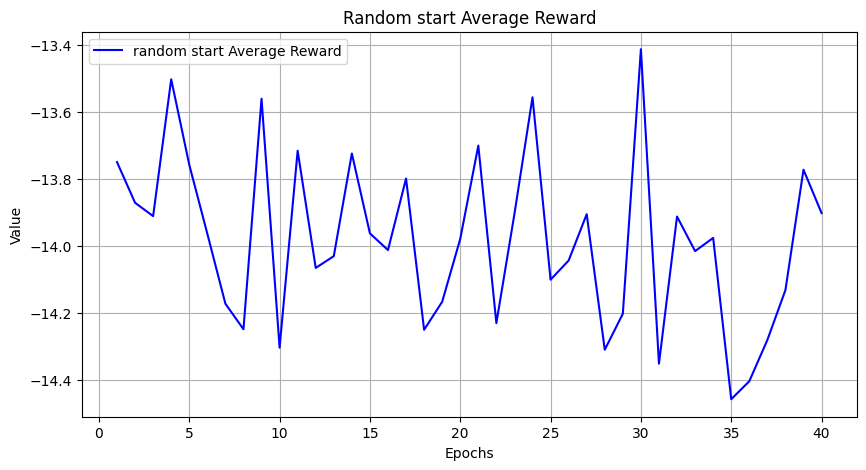

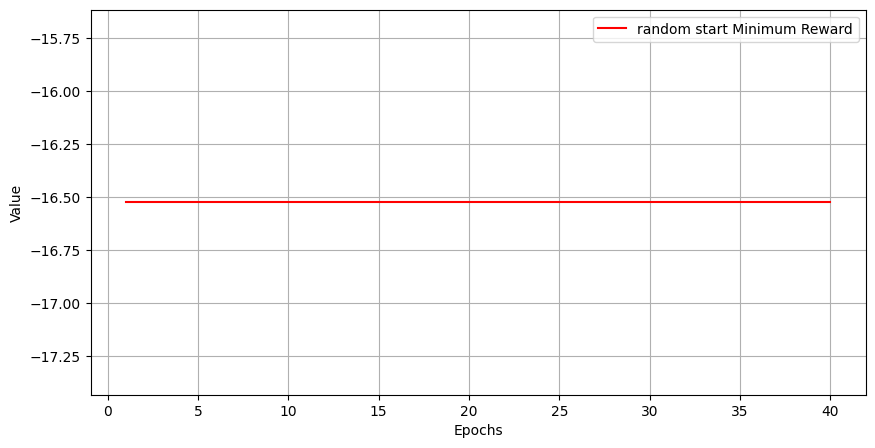

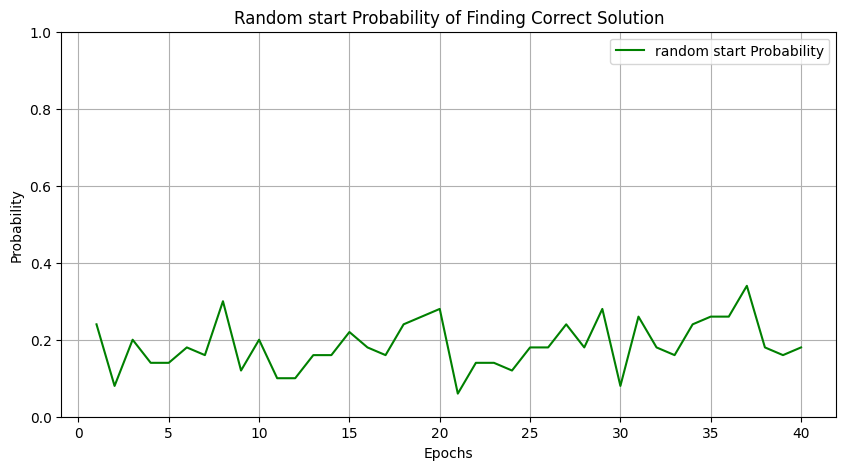

In [ ]:
import matplotlib.pyplot as plt

def plot_rl_qaoa_results(avg_values, min_values, prob_values):
    """
    Plots the stored training values of RL_QAOA across epochs with margin.

    - The first plot shows the average values over epochs with margin.
    - The second plot displays the minimum values over epochs with margin.
    - The third plot represents the probability of finding the correct solution.

    Parameters
    ----------
    avg_values : list
        List of average values over epochs.
    min_values : list
        List of minimum values over epochs.
    prob_values : list
        List of probabilities over epochs.

    The x-axis represents the number of epochs in all graphs.
    """

    epochs = range(1, len(avg_values) + 1)

    # Calculate margins for y-axis limits
    avg_min, avg_max = min(avg_values), max(avg_values)
    min_min, min_max = min(min_values), max(min_values)

    avg_margin = (avg_max - avg_min) * 0.05
    min_margin = (min_max - min_min) * 0.05

    # Plot average values with margin
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, avg_values, label="random start Average Reward", color='blue')
    plt.xlabel("Epochs")
    plt.ylabel("Value")
    plt.title("Random start Average Reward")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Plot minimum values with margin
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, min_values, label="random start Minimum Reward", color='red')
    plt.xlabel("Epochs")
    plt.ylabel("Value")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Plot probability values
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, prob_values, label="random start Probability", color='green')
    plt.xlabel("Epochs")
    plt.ylabel("Probability")
    plt.title("Random start Probability of Finding Correct Solution")
    plt.ylim(0, 1)  # Setting the y-axis range between 0 and 1
    plt.grid(True)
    plt.legend()
    plt.show()
# Example usage with dummy data
avg_values_random = rl_qaoa_const.avg_values
min_values_random = rl_qaoa_const.min_values
prob_values_random = rl_qaoa_const.prob_values

plot_rl_qaoa_results(avg_values_random, min_values_random, prob_values_random)



In [ ]:
def reduce_hamiltonian(Q_full, check_list):
    """
    Reduces the given Hamiltonian matrix by applying the constraint Z_k = sign * Z_l.

    Args:
        J (np.array): The initial Hamiltonian matrix (including diagonal terms).
        k (int): Index of the variable to be removed.
        l (int): Index of the variable to be replaced.
        node_assignments (dict): Dictionary mapping node indices to assignments.
        sign (int): Relationship (1 if identical, -1 if opposite).

    Returns:
        tuple: 
            - np.array: The reduced Hamiltonian matrix with the k-th variable removed.
            - np.array: An expanded version of the reduced matrix with extra rows and columns added back.
    """
    # Update interactions: J[i, l] = J[i, l] + sign * J[i, k]
 
    Q_full_copy = copy.deepcopy(Q_full)
    Q_full_copy = (Q_full_copy+Q_full_copy.T)/2
    for check in check_list:
        check_value = np.sign(check)*(abs(np.array(check))-1)

        if len(check)==1:
            pass
        else:
            for value in check_value[1:]:

                Q_full_copy[int(abs(check_value[0])),int(abs(check_value[0]))] += np.sign(value)*Q_full_copy[int(abs(value)),int(abs(value))] 
                for i in range(len(Q_full_copy)):
                    if i != int(abs(check_value[0])) and i != int(abs(value)):
                        Q_full_copy[int(abs(check_value[0])),i] += np.sign(value)*Q_full_copy[int(abs(value)),i]
                        Q_full_copy[i,int(abs(check_value[0]))] += np.sign(value)*Q_full_copy[i,int(abs(value))]
    keep_indices = []
    for check in check_list:
        check_value = np.sign(check)*(abs(np.array(check))-1)
        keep_indices.append(abs(int(check_value[0])))
    Q_full_copy = np.array(Q_full_copy)[np.ix_(keep_indices, keep_indices)]
    Q_full_copy = zero_lower_triangle(Q_full_copy)

    R = copy.deepcopy(Q_full_copy)

    remove_list = [x for x in range(len(Q_full)) if x not in keep_indices]
    # Add back zero rows and columns at specified indices
    for key in remove_list:
        R = add_zero_row_col(R, key)

                    

    return Q_full_copy, R